In [4]:
df = pd.read_csv("../../data/g1tfm-test-dataset-complete.csv", encoding="utf-8-sig")
df.head()


NameError: name 'pd' is not defined

In [5]:
#Importar libreria para manejo de datos
import pandas as pd

#Leer archivo de test
df = pd.read_csv("../../data/g1tfm-test-dataset-complete.csv")
#Imprimir primeras lineas para visualizar data
df.head()


,edad,ingresos_declarados,nivel_endeudamiento,utilizacion_tarjetas,score_buro,morosidad_prev,consumo_electrico,pago_serv_publicos,titularidad_serv_publico,remesas,ingresos_bancarios,historial_empresa,portabilidad,ultimo_consumo_movil,pago
0,56,329.522647,0.646939,47,98,23,262,0,1,200,545.845776,1,1,90,0
1,69,595.073122,0.869617,95,21,94,37,1,1,300,924.250560,0,0,14,1
2,46,626.490843,0.775897,69,96,64,297,1,0,200,719.689080,1,1,91,0
3,32,405.164365,0.630094,26,55,91,395,0,1,0,941.465720,1,0,45,0
4,60,345.645608,0.982259,46,20,112,365,0,1,0,470.641278,1,1,87,0


In [6]:
#Remover la variable de resultado del data set para crear variable X
X = df.drop("pago", axis=1)

#Definiiendo variable y como la columna de pago
y = df["pago"]


In [7]:
#Importar libreria auxiliar para ML
from sklearn.model_selection import train_test_split

#Dividir el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
#Importar el algoritmo seleccionado
#Se selecciono este algoritmo al ser el que presenta mejores resultados en un entranamiento de autoML
from xgboost import XGBClassifier

#Configuración de hyperparametros del algortimo
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


[23:45:52] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=200, n_jobs=4, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
              subsample=0.8, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [9]:
import warnings
warnings.filterwarnings("ignore")

#Se importan librerias auxiliares para metricas
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

#se corren los modelos
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Impresion de metricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.847
F1: 0.7570142932768661
AUC: 0.8481171229709242

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89      2109
           1       0.72      0.80      0.76       891

    accuracy                           0.85      3000
   macro avg       0.81      0.83      0.82      3000
weighted avg       0.85      0.85      0.85      3000



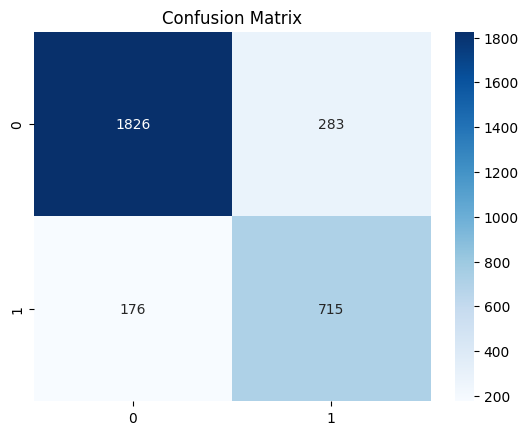

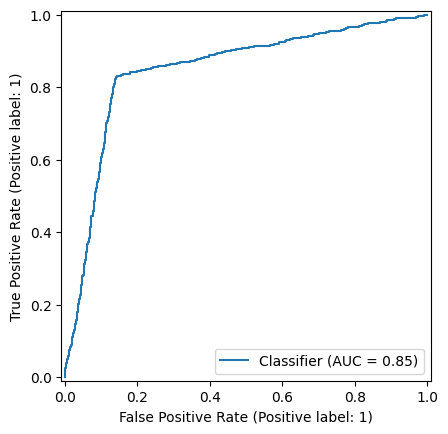

In [10]:
#Importar librerias para metricas visuales
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import seaborn as sns
#Libreria de diagramación
import matplotlib.pyplot as plt

#Creación de matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.show()

#Creación de Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


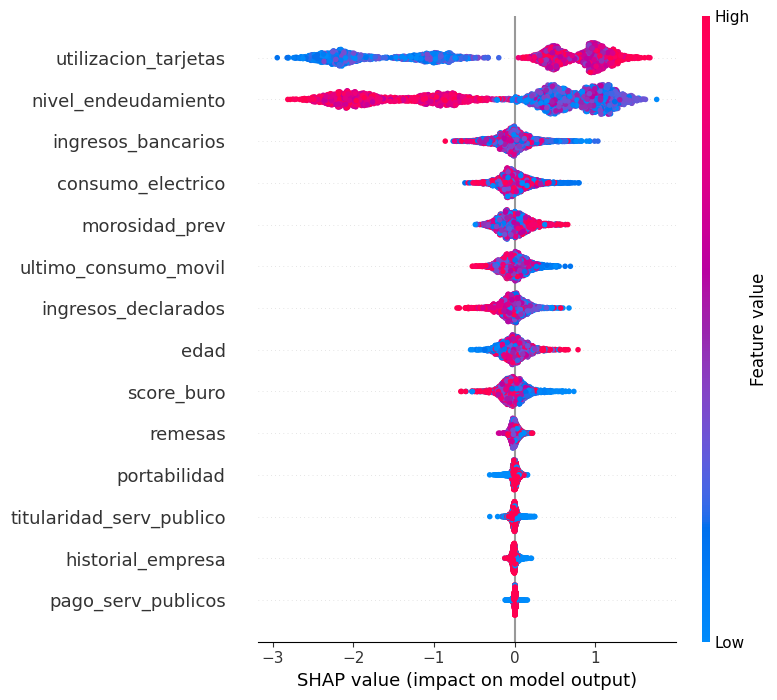

In [21]:
#Importar libreria que explica el modelo
#SHAP analiza tu modelo árbol‐basado (XGBoost) y calcula la contribución de cada variable a las predicciones.
import shap

#Explica el modelo basado en arboles
explainer = shap.TreeExplainer(model)
#Muestra ¿Cuánto contribuyó cada variable a la predicción del modelo para cada observación?
shap_values = explainer.shap_values(X_test)

#Grafica los resultados
shap.summary_plot(shap_values, X_test)


In [23]:
import joblib

joblib.dump(model, "g10tfm_model_test1.pkl")
print("Modelo guardado como g10tfm_model_test1.pkl ✓")


Modelo guardado como g10tfm_model_test1.pkl ✓


In [25]:
from azureml.core import Workspace, Model

ws = Workspace.from_config()

registered_model = Model.register(
    workspace=ws,
    model_path="g10tfm_model_test1.pkl",
    model_name="g1tfm_credit_scoring_model_test1",
    description="Modelo manual XGBoost para scoring crediticio"
)

print("Modelo registrado:", registered_model.name)

loaded = joblib.load("g10tfm_model_test1.pkl")

print("Modelo cargado OK")
print("Features:", loaded.get_booster().feature_names)

Registering model g1tfm_credit_scoring_model_test1
Modelo registrado: g1tfm_credit_scoring_model_test1
Modelo cargado OK
Features: ['edad', 'ingresos_declarados', 'nivel_endeudamiento', 'utilizacion_tarjetas', 'score_buro', 'morosidad_prev', 'consumo_electrico', 'pago_serv_publicos', 'titularidad_serv_publico', 'remesas', 'ingresos_bancarios', 'historial_empresa', 'portabilidad', 'ultimo_consumo_movil']


In [28]:
#Caso de uno para persona con deudas
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


test_case = pd.DataFrame([{
    'edad': 59,
    'ingresos_declarados': 350,
    'nivel_endeudamiento': 0.40,
    'utilizacion_tarjetas': 0.70,
    'score_buro': 513,
    'morosidad_prev': -3,
    'historial_empresa': 0,
    'consumo_electrico': 53,
    'pago_serv_publicos': 0,
    'titularidad_serv_publico': 0,
    'remesas': 0,
    'ingresos_bancarios': 400,
    'ultimo_consumo_movil': 0,
    'portabilidad': 0
}])

pred = loaded.predict(test_case)
proba = loaded.predict_proba(test_case)

print("Pred:", int(pred[0]))
print("Probabilidad de pago:", float(proba[0][1])*100,"%")

Pred: 0
Probabilidad de pago: 26.5484482049942 %


In [29]:
#Caso de uso para persona solvente con buenos ingresos
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


test_case = pd.DataFrame([{
    'edad': 35,
    'ingresos_declarados': 1550,
    'nivel_endeudamiento': 0.1711,
    'utilizacion_tarjetas': 0.20,
    'score_buro': 930,
    'morosidad_prev': 0,
    'historial_empresa': 1,
    'consumo_electrico': 396,
    'pago_serv_publicos': 1,
    'titularidad_serv_publico': 1,
    'remesas': 500,
    'ingresos_bancarios': 2100,
    'ultimo_consumo_movil': 80,
    'portabilidad': 1
}])

pred = loaded.predict(test_case)
proba = loaded.predict_proba(test_case)

print("Pred:", int(pred[0]))
print("Probabilidad de pago:", float(proba[0][1])*100,"%")


Pred: 0
Probabilidad de pago: 7.145253568887711 %
